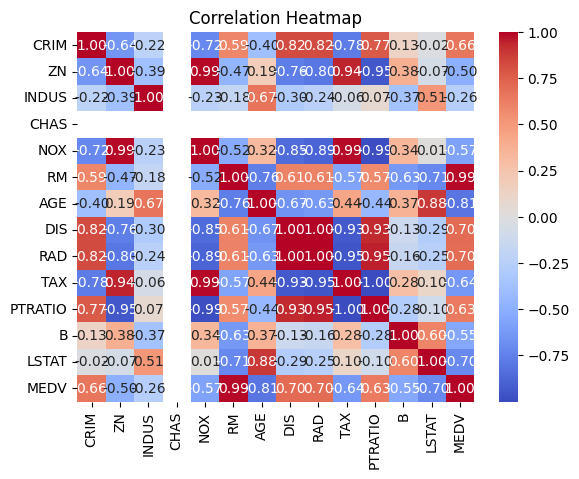

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

data=pd.read_csv('boston_data_sample.csv')
corr_arr=data.corr()

sns.heatmap(corr_arr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [ ]:

medv_corr = corr_arr["MEDV"].drop("MEDV")

top_2_features = medv_corr.abs().sort_values(ascending=False).head(2)
print("Top 2 features most correlated with MEDV:")
print(top_2_features)


Top 2 features most correlated with MEDV:
RM     0.989842
AGE    0.811109
Name: MEDV, dtype: float64


In [3]:
from sklearn.model_selection import train_test_split

# Chọn 2 cột vừa tìm được ở trên để dự đoán MEDV
X = data[top_2_features.index.tolist()]
y = data["MEDV"]

# Chia dữ liệu: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


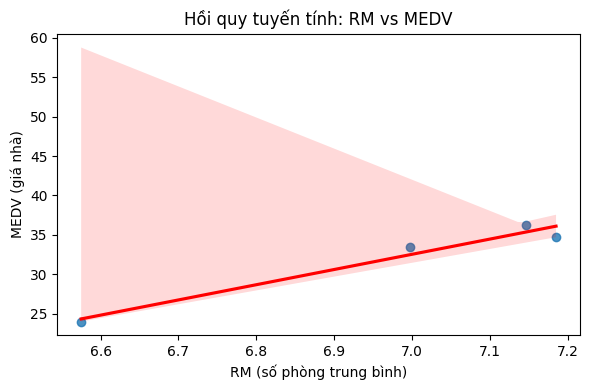

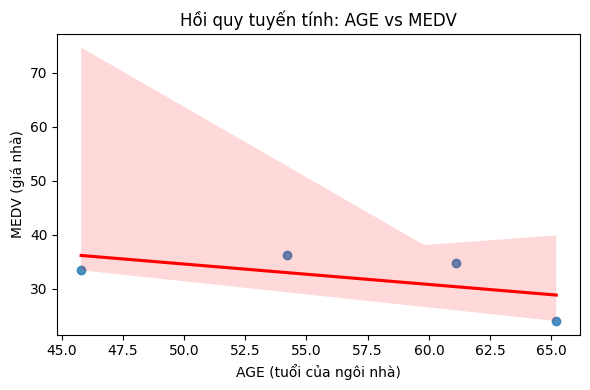

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vẽ hồi quy RM vs MEDV
plt.figure(figsize=(6, 4))
sns.regplot(x=X_train["RM"], y=y_train, line_kws={"color": "red"})
plt.title("Hồi quy tuyến tính: RM vs MEDV")
plt.xlabel("RM (số phòng trung bình)")
plt.ylabel("MEDV (giá nhà)")
plt.tight_layout()
plt.show()

# Vẽ hồi quy AGE vs MEDV
plt.figure(figsize=(6, 4))
sns.regplot(x=X_train["AGE"], y=y_train, line_kws={"color": "red"})
plt.title("Hồi quy tuyến tính: AGE vs MEDV")
plt.xlabel("AGE (tuổi của ngôi nhà)")
plt.ylabel("MEDV (giá nhà)")
plt.tight_layout()
plt.show()


In [5]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Tính RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 2.0272020391006365
